<div dir="rtl">

# نوت‌بوک ۱: طبقه‌بندی ارقام دست‌نویس MNIST با شبکه عصبی MLPClassifier

در این نوت‌بوک یک **شبکه عصبی پرسپترون چندلایه (Multi-Layer Perceptron)** را با کتابخانه `scikit-learn` روی مجموعه‌داده معروف **MNIST** آموزش می‌دهیم و سپس عملکرد آن را با ابزارهای مختلف ارزیابی می‌کنیم.

### اهداف آموزشی
1. آشنایی با دیتاست MNIST (۶۰۰۰۰ تصویر آموزشی و ۱۰۰۰۰ تصویر آزمون، هر تصویر ۲۸×۲۸ پیکسل)
2. ساخت، آموزش و ارزیابی `MLPClassifier`
3. رسم و تفسیر نمودارهای ارزیابی:
   - **Loss Curve** (منحنی خطا)
   - **Accuracy Curve** (منحنی دقت در طول آموزش)
   - **Learning Curve** (منحنی یادگیری بر حسب اندازه داده)
   - **Precision-Recall Curve**
   - **ROC Curve**
4. استفاده از **Cross Validation** (اعتبارسنجی متقابل) و رسم نمودار دقت آن

### فهرست مطالب
| بخش | عنوان |
|---|---|
| ۱ | وارد کردن کتابخانه‌ها |
| ۲ | بارگذاری و آشنایی با داده |
| ۳ | پیش‌پردازش |
| ۴ | معرفی شبکه MLP و پارامترهای آن |
| ۵ | آموزش مدل روی ۶۰۰۰۰ تصویر |
| ۶ | ارزیابی دقت مدل |
| ۷ | Loss Curve |
| ۸ | Accuracy Curve |
| ۹ | Learning Curve |
| ۱۰ | Precision-Recall Curve |
| ۱۱ | ROC Curve |
| ۱۲ | جمع‌بندی نمودارها |
| ۱۳ | Cross Validation |
| ۱۴ | مصورسازی وزن‌های آموخته‌شده |
| ۱۵ | جمع‌بندی و تمرین |

> **نکته:** برچسب‌ها و عنوان‌های داخل نمودارها به انگلیسی نوشته شده‌اند، چون `matplotlib` به‌طور پیش‌فرض حروف فارسی را درست نمایش نمی‌دهد.

</div>

<div dir="rtl">

## ۱. وارد کردن کتابخانه‌ها

- `numpy` و `pandas`: کار با آرایه‌ها و جدول‌ها
- `matplotlib` و `seaborn`: رسم نمودار
- `sklearn.datasets.fetch_openml`: دانلود دیتاست MNIST از سایت OpenML
- `sklearn.neural_network.MLPClassifier`: شبکه عصبی چندلایه
- `sklearn.model_selection`: ابزارهای تقسیم داده، اعتبارسنجی متقابل و منحنی یادگیری
- `sklearn.metrics`: معیارهای ارزیابی

مقدار `RANDOM_STATE` را ثابت می‌گذاریم تا نتایج **تکرارپذیر** باشند.

</div>

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_score, learning_curve, validation_curve)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, log_loss, precision_recall_curve,
                             average_precision_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})

<div dir="rtl">

## ۲. بارگذاری و آشنایی با داده MNIST

**MNIST** شامل ۷۰۰۰۰ تصویر سیاه‌وسفید از ارقام دست‌نویس ۰ تا ۹ است:
- هر تصویر **۲۸×۲۸ = ۷۸۴ پیکسل** دارد و هر پیکسل عددی بین ۰ (سفید) تا ۲۵۵ (سیاه) است.
- هر تصویر به یک **بردار ۷۸۴ بعدی** تبدیل (flatten) شده است؛ یعنی MLP ساختار دوبعدی تصویر را نمی‌بیند و فقط یک بردار عددی دریافت می‌کند.
- تقسیم استاندارد: **۶۰۰۰۰ نمونه اول برای آموزش** و **۱۰۰۰۰ نمونه آخر برای آزمون**.

تابع `fetch_openml` بار اول داده را دانلود می‌کند (حدود ۱۵ مگابایت) و در پوشه `~/scikit_learn_data` ذخیره می‌کند؛ دفعات بعد از حافظه محلی خوانده می‌شود.

</div>

In [2]:
t0 = time.time()
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)
print(f'Loaded in {time.time() - t0:.1f}s  ->  X: {X.shape}, y: {y.shape}')

# standard split: 60,000 train / 10,000 test
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Pixel range:', X.min(), 'to', X.max())

Loaded in 4.3s  ->  X: (70000, 784), y: (70000,)
Train: (60000, 784)  Test: (10000, 784)
Pixel range: 0.0 to 255.0


<div dir="rtl">

### ۲-۱. نمایش چند نمونه تصادفی
هر بردار ۷۸۴تایی را با `reshape(28, 28)` دوباره به تصویر تبدیل و نمایش می‌دهیم.

</div>

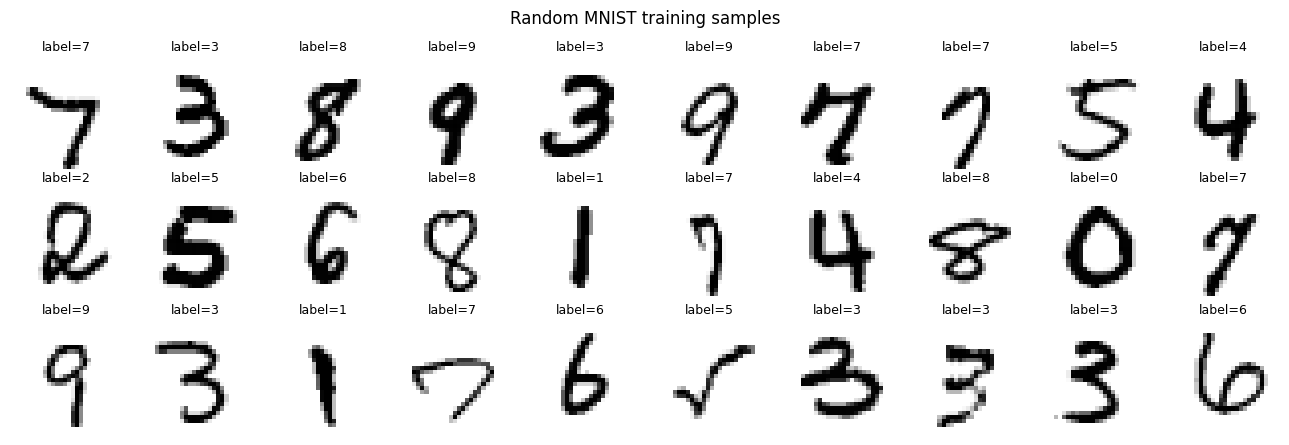

In [3]:
fig, axes = plt.subplots(3, 10, figsize=(13, 4.5))
for ax, i in zip(axes.ravel(), np.random.choice(len(X_train), 30, replace=False)):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f'label={y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Random MNIST training samples')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۲-۲. توزیع کلاس‌ها
قبل از هر مدل‌سازی باید بدانیم داده **متوازن (balanced)** است یا نه. اگر یک کلاس خیلی بیشتر از بقیه باشد، معیار Accuracy می‌تواند گمراه‌کننده باشد و باید به Precision/Recall توجه بیشتری کرد.

</div>

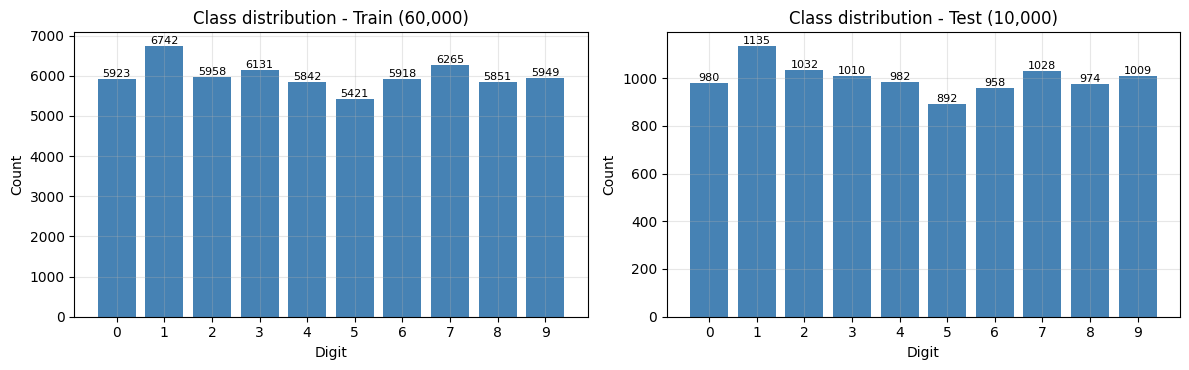

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, labels, name in [(axes[0], y_train, 'Train (60,000)'), (axes[1], y_test, 'Test (10,000)')]:
    counts = pd.Series(labels).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='steelblue')
    ax.set_xticks(range(10))
    ax.set_title(f'Class distribution - {name}')
    ax.set_xlabel('Digit'); ax.set_ylabel('Count')
    for d, c in counts.items():
        ax.text(d, c, str(c), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۲-۳. میانگین تصویر هر رقم
میانگین پیکسل‌های همه تصاویر یک کلاس، «شکل نمونه» آن رقم را نشان می‌دهد. این شهود می‌دهد که مدل باید چه الگوهایی را یاد بگیرد.

</div>

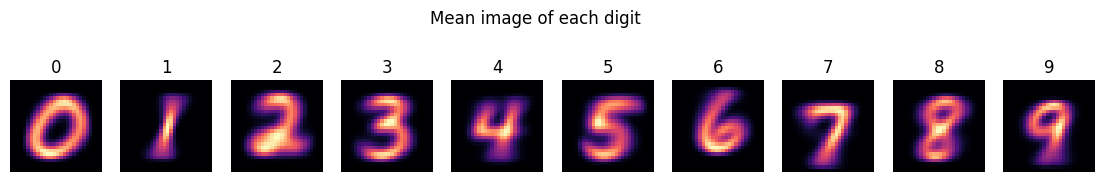

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for d in range(10):
    axes[d].imshow(X_train[y_train == d].mean(axis=0).reshape(28, 28), cmap='magma')
    axes[d].set_title(str(d)); axes[d].axis('off')
plt.suptitle('Mean image of each digit', y=1.08)
plt.show()

<div dir="rtl">

## ۳. پیش‌پردازش: مقیاس‌بندی (Scaling)

شبکه‌های عصبی با **گرادیان کاهشی** آموزش می‌بینند و به مقیاس ورودی‌ها حساس‌اند. اگر ورودی‌ها بزرگ باشند (۰ تا ۲۵۵):
- فعال‌سازی نورون‌ها بسیار بزرگ می‌شود و آموزش ناپایدار می‌شود؛
- نرخ یادگیری مناسب به‌سختی پیدا می‌شود.

ساده‌ترین روش برای تصاویر، تقسیم بر ۲۵۵ است تا مقادیر در بازه $[0, 1]$ قرار بگیرند:

$$x_{scaled} = \frac{x}{255}$$

(روش دیگر `StandardScaler` است که میانگین را صفر و انحراف معیار را یک می‌کند.)

</div>

In [6]:
X_train_s = X_train / 255.0
X_test_s = X_test / 255.0
print('New range:', X_train_s.min(), 'to', X_train_s.max())

New range: 0.0 to 1.0


<div dir="rtl">

## ۴. معرفی شبکه عصبی MLP

یک MLP از چند **لایه کاملاً متصل (fully connected)** تشکیل شده است:

```
ورودی (784)  →  لایه پنهان ۱ (256 نورون, ReLU)  →  لایه پنهان ۲ (128 نورون, ReLU)  →  خروجی (10 نورون, Softmax)
```

در هر لایه، خروجی به صورت زیر محاسبه می‌شود:

$$h = f(W x + b)$$

که $W$ ماتریس وزن، $b$ بایاس و $f$ تابع فعال‌سازی است. لایه آخر با **Softmax** برای هر کلاس یک احتمال تولید می‌کند:

$$P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=0}^{9} e^{z_j}}$$

تابع هزینه (Loss) در طبقه‌بندی، **Cross-Entropy** است:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \log P(y_i \mid x_i) + \frac{\alpha}{2n}\lVert W \rVert_2^2$$

جمله دوم **تنظیم‌سازی L2** است که با پارامتر `alpha` کنترل می‌شود و جلوی بیش‌برازش (Overfitting) را می‌گیرد.

### پارامترهای مهم `MLPClassifier`
| پارامتر | مقدار ما | توضیح |
|---|---|---|
| `hidden_layer_sizes` | `(256, 128)` | تعداد نورون‌های هر لایه پنهان |
| `activation` | `'relu'` | تابع فعال‌سازی: $\max(0, z)$ |
| `solver` | `'adam'` | الگوریتم بهینه‌سازی (Adam برای داده‌های بزرگ مناسب است) |
| `alpha` | `1e-4` | ضریب تنظیم‌سازی L2 |
| `batch_size` | `128` | اندازه مینی‌بچ |
| `learning_rate_init` | `1e-3` | نرخ یادگیری اولیه |
| `max_iter` | `50` | حداکثر تعداد **Epoch** (هر epoch یعنی یک بار دیدن کل داده) |
| `early_stopping` | `True` | ۱۰٪ داده آموزش را برای اعتبارسنجی کنار می‌گذارد و اگر دقت روی آن بهتر نشد، آموزش را متوقف می‌کند |
| `n_iter_no_change` | `5` | تعداد epochهایی که بدون بهبود صبر می‌کند |

</div>

<div dir="rtl">

## ۵. آموزش مدل روی ۶۰۰۰۰ تصویر آموزشی

با فراخوانی `fit` مدل آموزش می‌بیند. چون `early_stopping=True` است، `scikit-learn` در داخل خودش ۱۰٪ از ۶۰۰۰۰ نمونه (۶۰۰۰ نمونه) را برای پایش دقت کنار می‌گذارد و روی ۵۴۰۰۰ نمونه دیگر وزن‌ها را به‌روز می‌کند.

بعد از آموزش، این ویژگی‌ها در دسترس هستند:
- `loss_curve_`: مقدار Loss در هر epoch
- `validation_scores_`: دقت روی داده اعتبارسنجی داخلی در هر epoch
- `n_iter_`: تعداد epochهای اجراشده
- `coefs_` و `intercepts_`: وزن‌ها و بایاس‌های آموخته‌شده

</div>

In [7]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                    alpha=1e-4, batch_size=128, learning_rate_init=1e-3,
                    max_iter=50, early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=5, random_state=RANDOM_STATE)

t0 = time.time()
mlp.fit(X_train_s, y_train)
train_time = time.time() - t0

n_params = sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)
print(f'Training time        : {train_time:.1f} s')
print(f'Epochs run           : {mlp.n_iter_}')
print(f'Trainable parameters : {n_params:,}')
print(f'Best validation acc  : {mlp.best_validation_score_:.4f}')

Training time        : 102.9 s
Epochs run           : 16
Trainable parameters : 235,146
Best validation acc  : 0.9782


<div dir="rtl">

## ۶. ارزیابی دقت مدل

### ۶-۱. دقت (Accuracy) روی داده آموزش و آزمون
$$\text{Accuracy} = \frac{\text{تعداد پیش‌بینی‌های درست}}{\text{تعداد کل نمونه‌ها}}$$

مقایسه دقت آموزش و آزمون مهم است: اگر دقت آموزش خیلی بیشتر از آزمون باشد، مدل **بیش‌برازش (Overfitting)** دارد.

</div>

In [8]:
y_pred = mlp.predict(X_test_s)
proba = mlp.predict_proba(X_test_s)          # shape (10000, 10): probability of each class

train_acc = accuracy_score(y_train, mlp.predict(X_train_s))
test_acc = accuracy_score(y_test, y_pred)
print(f'Train accuracy : {train_acc:.4f}')
print(f'Test  accuracy : {test_acc:.4f}')
print(f'Test  error    : {1 - test_acc:.4f}  ->  {int((1 - test_acc) * len(y_test))} misclassified images')

Train accuracy : 0.9963
Test  accuracy : 0.9788
Test  error    : 0.0212  ->  211 misclassified images


<div dir="rtl">

### ۶-۲. گزارش طبقه‌بندی (Classification Report)
برای هر کلاس سه معیار گزارش می‌شود:
- **Precision (دقت پیش‌بینی):** از بین نمونه‌هایی که مدل گفته «کلاس k»، چند درصد واقعاً k بوده‌اند؟ $\frac{TP}{TP+FP}$
- **Recall (بازیابی/حساسیت):** از بین نمونه‌های واقعی کلاس k، مدل چند درصد را پیدا کرده؟ $\frac{TP}{TP+FN}$
- **F1-score:** میانگین هارمونیک این دو: $F_1 = 2\cdot\frac{P \cdot R}{P+R}$
- **support:** تعداد نمونه‌های واقعی آن کلاس

</div>

In [9]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9808    0.9908    0.9858       980
           1     0.9920    0.9885    0.9903      1135
           2     0.9713    0.9835    0.9774      1032
           3     0.9839    0.9693    0.9766      1010
           4     0.9875    0.9633    0.9753       982
           5     0.9886    0.9753    0.9819       892
           6     0.9682    0.9854    0.9767       958
           7     0.9720    0.9786    0.9753      1028
           8     0.9734    0.9784    0.9759       974
           9     0.9704    0.9732    0.9718      1009

    accuracy                         0.9788     10000
   macro avg     0.9788    0.9787    0.9787     10000
weighted avg     0.9789    0.9788    0.9788     10000



<div dir="rtl">

### ۶-۳. ماتریس درهم‌ریختگی (Confusion Matrix)
سطرها **برچسب واقعی** و ستون‌ها **پیش‌بینی مدل** هستند. قطر اصلی پیش‌بینی‌های درست است و خانه‌های بیرون قطر نشان می‌دهند مدل کدام ارقام را با هم اشتباه می‌گیرد (مثلاً ۴ و ۹، یا ۳ و ۵). نسخه نرمال‌شده (بر اساس سطر) همان Recall هر کلاس را روی قطر نشان می‌دهد.

</div>

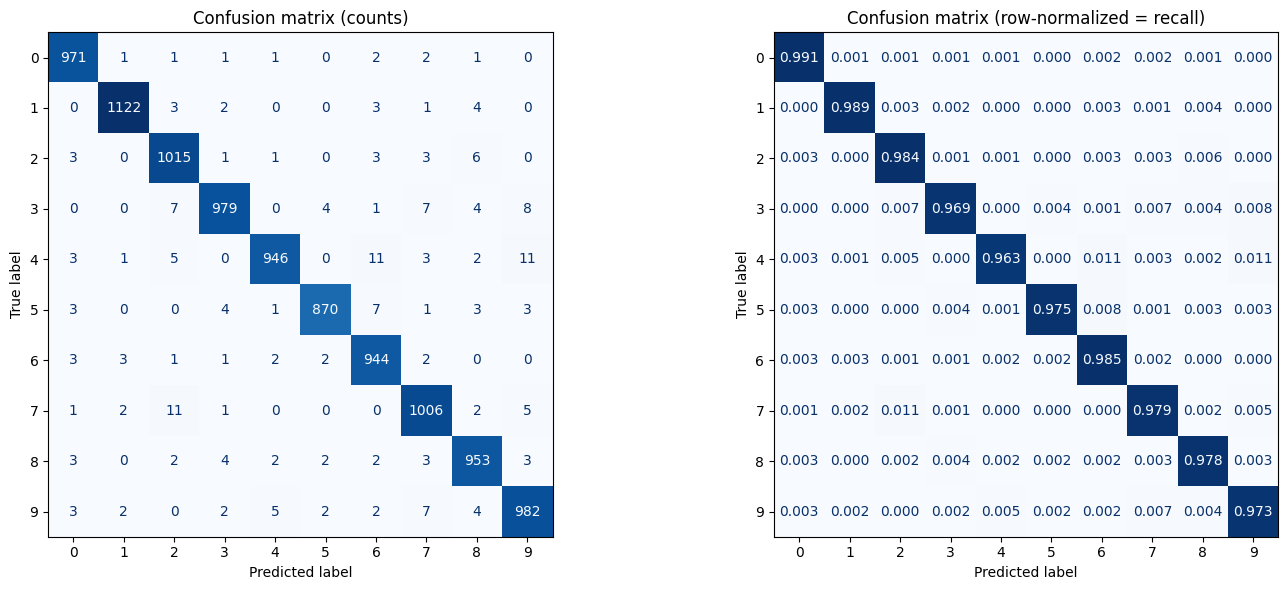

Top-5 confusions (true -> predicted):
   7 -> 2: 11 times
   4 -> 9: 11 times
   4 -> 6: 11 times
   3 -> 9: 8 times
   9 -> 7: 7 times


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix (counts)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], cmap='Blues', colorbar=False,
                                        normalize='true', values_format='.3f')
axes[1].set_title('Confusion matrix (row-normalized = recall)')
for ax in axes:
    ax.grid(False)
plt.tight_layout()
plt.show()

# the most frequent confusions
cm = confusion_matrix(y_test, y_pred)
np.fill_diagonal(cm, 0)
pairs = sorted([(cm[i, j], i, j) for i in range(10) for j in range(10) if cm[i, j] > 0], reverse=True)[:5]
print('Top-5 confusions (true -> predicted):')
for c, i, j in pairs:
    print(f'   {i} -> {j}: {c} times')

<div dir="rtl">

### ۶-۴. نمایش نمونه‌هایی که اشتباه طبقه‌بندی شده‌اند
دیدن خطاها به ما شهود می‌دهد: بسیاری از آن‌ها حتی برای انسان هم مبهم هستند. عدد داخل پرانتز، احتمالی است که مدل به پیش‌بینی (اشتباه) خود داده است.

</div>

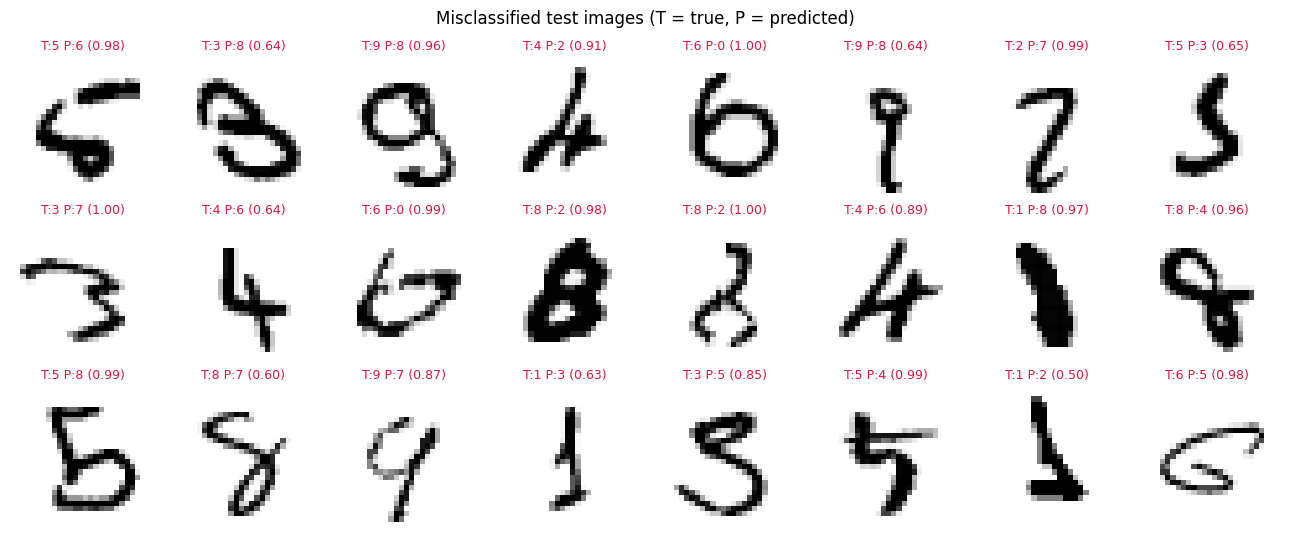

In [11]:
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(3, 8, figsize=(13, 5.5))
for ax, i in zip(axes.ravel(), wrong[:24]):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray_r')
    ax.set_title(f'T:{y_test[i]} P:{y_pred[i]} ({proba[i].max():.2f})', fontsize=9, color='crimson')
    ax.axis('off')
plt.suptitle('Misclassified test images (T = true, P = predicted)')
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۷. منحنی خطا (Loss Curve)

### چیست؟
نمودار **مقدار تابع هزینه (Loss)** بر حسب **شماره Epoch** است. محور افقی زمان آموزش و محور عمودی میزان خطای مدل روی داده آموزش را نشان می‌دهد.

### کاربرد
- **بررسی همگرایی:** اگر Loss به یک مقدار ثابت رسیده، ادامه آموزش فایده چندانی ندارد.
- **تشخیص مشکل نرخ یادگیری:**
  - نرخ یادگیری **خیلی کوچک** ← Loss خیلی آهسته کم می‌شود.
  - نرخ یادگیری **خیلی بزرگ** ← Loss نوسان می‌کند یا حتی زیاد می‌شود.
- **تشخیص بیش‌برازش:** اگر Loss آموزش مدام کم شود ولی دقت/Loss اعتبارسنجی بدتر شود، مدل در حال حفظ کردن داده آموزش است.

در `MLPClassifier` ویژگی `loss_curve_` مقدار Loss آموزش (شامل جمله تنظیم‌سازی L2) و `validation_scores_` دقت روی داده اعتبارسنجی داخلی را در هر epoch ذخیره می‌کند.

</div>

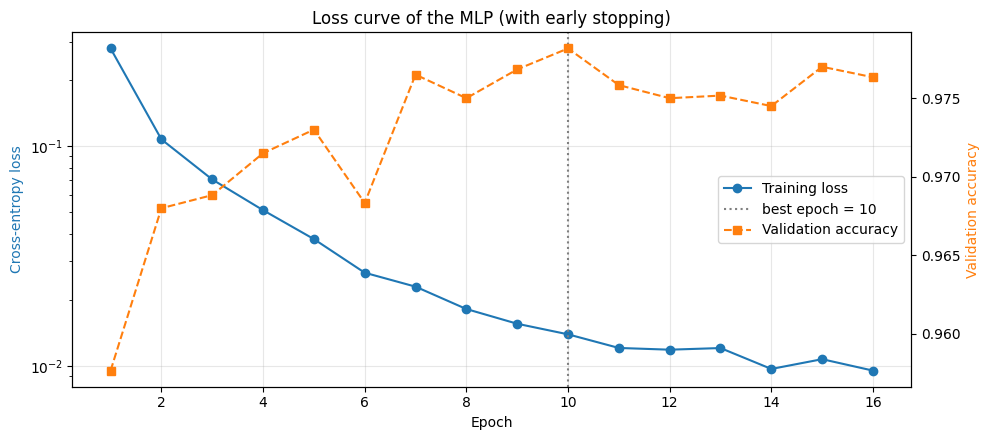

In [12]:
epochs = np.arange(1, len(mlp.loss_curve_) + 1)
best_epoch = int(np.argmax(mlp.validation_scores_)) + 1

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(epochs, mlp.loss_curve_, 'o-', color='tab:blue', label='Training loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss', color='tab:blue')
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(epochs, mlp.validation_scores_, 's--', color='tab:orange', label='Validation accuracy')
ax2.set_ylabel('Validation accuracy', color='tab:orange')
ax2.grid(False)
ax1.axvline(best_epoch, color='gray', ls=':', label=f'best epoch = {best_epoch}')

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc='center right')
plt.title('Loss curve of the MLP (with early stopping)')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۷-۱. آزمایش: اثر نرخ یادگیری روی Loss Curve
برای درک بهتر، چهار مدل با نرخ یادگیری مختلف را روی یک زیرمجموعه ۱۰۰۰۰تایی آموزش می‌دهیم و منحنی Loss آن‌ها را مقایسه می‌کنیم. (برای سرعت از زیرمجموعه استفاده شده است.)

</div>

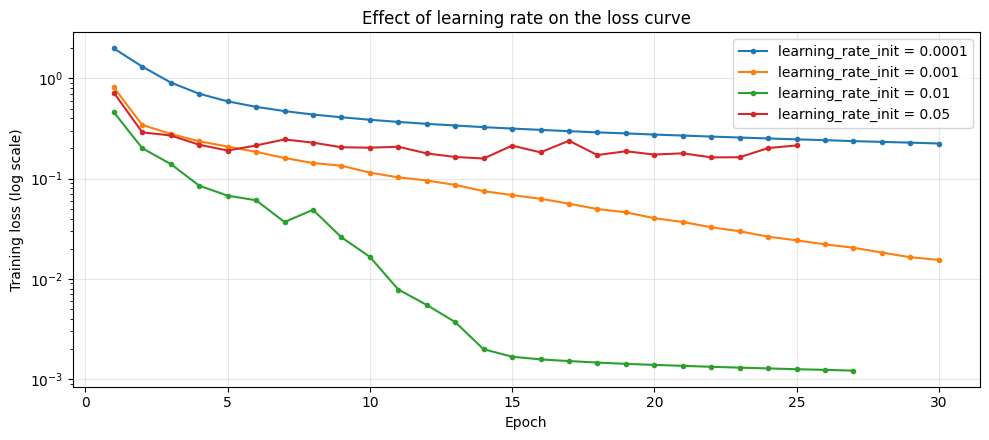

In [13]:
idx_small, _ = train_test_split(np.arange(len(y_train)), train_size=10000,
                                stratify=y_train, random_state=RANDOM_STATE)
X_small, y_small = X_train_s[idx_small], y_train[idx_small]

plt.figure(figsize=(10, 4.5))
for lr in [1e-4, 1e-3, 1e-2, 5e-2]:
    m = MLPClassifier(hidden_layer_sizes=(128,), learning_rate_init=lr, max_iter=30,
                      batch_size=128, random_state=RANDOM_STATE)
    try:
        m.fit(X_small, y_small)
        plt.plot(np.arange(1, len(m.loss_curve_) + 1), m.loss_curve_, 'o-', ms=3,
                 label=f'learning_rate_init = {lr:g}')
    except ValueError as e:        # diverged (non-finite weights)
        print(f'lr={lr:g} diverged: {e}')
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Training loss (log scale)')
plt.title('Effect of learning rate on the loss curve')
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:**
- نرخ یادگیری خیلی کوچک (`1e-4`): کاهش Loss کند است و در ۳۰ epoch به کمینه نمی‌رسد.
- نرخ مناسب (`1e-3`): کاهش سریع و پایدار.
- نرخ نسبتاً بزرگ (`1e-2`): روی این زیرمجموعه کوچک، Loss آموزش سریع‌تر پایین می‌آید، اما منحنی **ناهموار** است (پرش‌ها در epochهای میانی). توجه کنید Loss آموزشِ کمتر لزوماً به معنای تعمیم بهتر نیست.
- نرخ خیلی بزرگ (`5e-2`): Loss بعد از چند epoch **نوسان** می‌کند و در سطح بالایی می‌ماند، چون گام‌های بهینه‌سازی از روی کمینه می‌پرند؛ آموزش هم به دلیل عدم بهبود زودتر متوقف شده است.

</div>

<div dir="rtl">

## ۸. منحنی دقت (Accuracy Curve)

### چیست؟
نمودار **دقت مدل روی داده آموزش و اعتبارسنجی** بر حسب **Epoch** است. معمولاً کنار آن منحنی Loss اعتبارسنجی را هم رسم می‌کنیم.

### کاربرد
- **انتخاب تعداد مناسب Epoch:** نقطه‌ای که دقت اعتبارسنجی بیشینه است.
- **تشخیص بیش‌برازش:** وقتی دقت آموزش به ۱۰۰٪ نزدیک می‌شود ولی دقت اعتبارسنجی ثابت می‌ماند یا کم می‌شود، و **Loss اعتبارسنجی شروع به افزایش می‌کند**.
- **تشخیص کم‌برازش (Underfitting):** اگر هر دو منحنی پایین باشند، مدل ظرفیت کافی ندارد.

### روش کار
`MLPClassifier.fit` دقت آموزش را در هر epoch ذخیره نمی‌کند؛ بنابراین از `partial_fit` استفاده می‌کنیم. **هر بار فراخوانی `partial_fit` روی کل داده، دقیقاً یک epoch آموزش** است (با مینی‌بچ‌ها و بُر زدن داده). بعد از هر epoch، دقت و Loss را روی داده آموزش و اعتبارسنجی حساب می‌کنیم.

برای این کار ۶۰۰۰۰ داده آموزش را به **۵۰۰۰۰ آموزش + ۱۰۰۰۰ اعتبارسنجی** تقسیم می‌کنیم (داده آزمون را دست نمی‌زنیم).

</div>

In [14]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train_s, y_train, test_size=10000,
                                            stratify=y_train, random_state=RANDOM_STATE)
classes = np.arange(10)
EPOCHS = 30

mlp_hist = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
                         alpha=1e-4, batch_size=128, learning_rate_init=1e-3,
                         random_state=RANDOM_STATE)
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    mlp_hist.partial_fit(X_tr, y_tr, classes=classes)      # one epoch
    p_tr, p_val = mlp_hist.predict_proba(X_tr), mlp_hist.predict_proba(X_val)
    history['train_loss'].append(log_loss(y_tr, p_tr, labels=classes))
    history['val_loss'].append(log_loss(y_val, p_val, labels=classes))
    history['train_acc'].append(np.mean(p_tr.argmax(1) == y_tr))
    history['val_acc'].append(np.mean(p_val.argmax(1) == y_val))
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d} | train_loss {history['train_loss'][-1]:.4f} "
              f"| val_loss {history['val_loss'][-1]:.4f} | train_acc {history['train_acc'][-1]:.4f} "
              f"| val_acc {history['val_acc'][-1]:.4f}")
print(f'Total time: {time.time() - t0:.1f} s')
hist_df = pd.DataFrame(history, index=pd.RangeIndex(1, EPOCHS + 1, name='epoch'))

epoch  1 | train_loss 0.1211 | val_loss 0.1467 | train_acc 0.9664 | val_acc 0.9595


epoch  5 | train_loss 0.0231 | val_loss 0.0845 | train_acc 0.9933 | val_acc 0.9746


epoch 10 | train_loss 0.0149 | val_loss 0.1030 | train_acc 0.9951 | val_acc 0.9761


epoch 15 | train_loss 0.0049 | val_loss 0.1008 | train_acc 0.9984 | val_acc 0.9792


epoch 20 | train_loss 0.0062 | val_loss 0.1090 | train_acc 0.9982 | val_acc 0.9798


epoch 25 | train_loss 0.0094 | val_loss 0.1271 | train_acc 0.9974 | val_acc 0.9772


epoch 30 | train_loss 0.0064 | val_loss 0.1428 | train_acc 0.9980 | val_acc 0.9775
Total time: 300.2 s


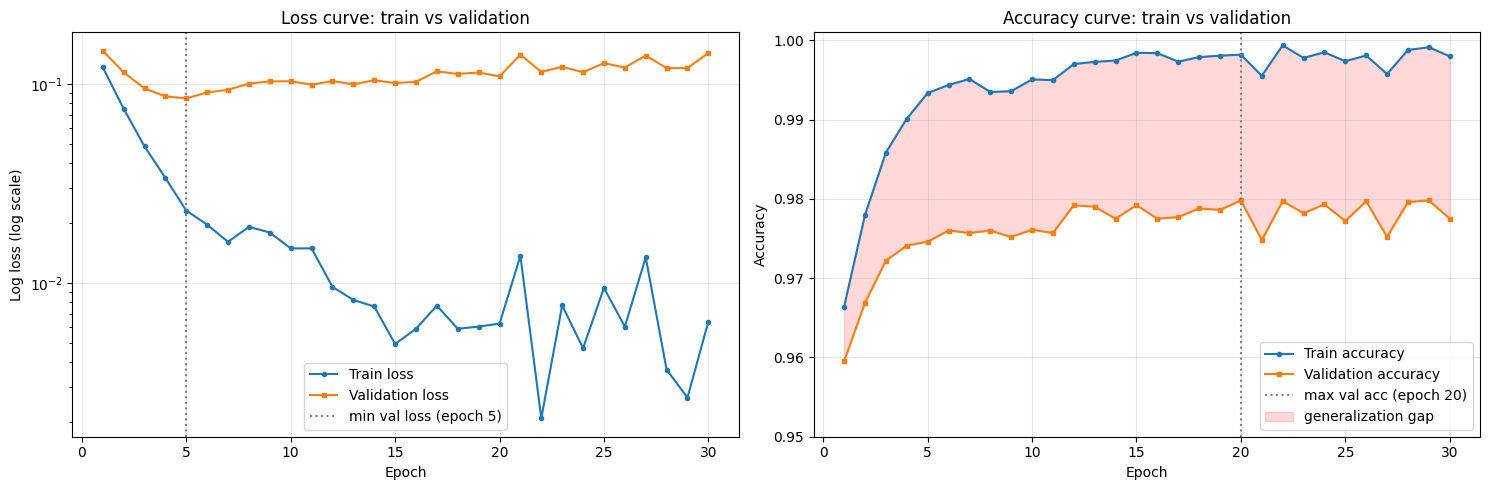

Best validation accuracy 0.9798 at epoch 20
Final train acc 0.9980 | final val acc 0.9775
Test accuracy of this model: 0.9759


In [15]:
ep = hist_df.index
best_acc_ep = hist_df['val_acc'].idxmax()
best_loss_ep = hist_df['val_loss'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ep, hist_df['train_loss'], 'o-', ms=3, label='Train loss')
axes[0].plot(ep, hist_df['val_loss'], 's-', ms=3, label='Validation loss')
axes[0].axvline(best_loss_ep, color='gray', ls=':', label=f'min val loss (epoch {best_loss_ep})')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Log loss (log scale)')
axes[0].set_title('Loss curve: train vs validation'); axes[0].legend()

axes[1].plot(ep, hist_df['train_acc'], 'o-', ms=3, label='Train accuracy')
axes[1].plot(ep, hist_df['val_acc'], 's-', ms=3, label='Validation accuracy')
axes[1].axvline(best_acc_ep, color='gray', ls=':', label=f'max val acc (epoch {best_acc_ep})')
axes[1].fill_between(ep, hist_df['val_acc'], hist_df['train_acc'], alpha=0.15, color='red',
                     label='generalization gap')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.95, 1.001)
axes[1].set_title('Accuracy curve: train vs validation'); axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Best validation accuracy {hist_df['val_acc'].max():.4f} at epoch {best_acc_ep}")
print(f"Final train acc {hist_df['train_acc'].iloc[-1]:.4f} | final val acc {hist_df['val_acc'].iloc[-1]:.4f}")
print(f"Test accuracy of this model: {mlp_hist.score(X_test_s, y_test):.4f}")

<div dir="rtl">

**تفسیر:**
- **دقت آموزش** به‌سرعت به نزدیک ۱۰۰٪ می‌رسد، اما **دقت اعتبارسنجی** بعد از چند epoch تقریباً ثابت می‌ماند. ناحیه قرمز فاصله تعمیم (Generalization Gap) است.
- **Loss اعتبارسنجی** بعد از یک نقطه کمینه **شروع به افزایش می‌کند** در حالی که Loss آموزش همچنان کم می‌شود. این نشانه کلاسیک **بیش‌برازش** است: مدل روی داده‌های آموزش بیش از حد مطمئن شده است.
- راه‌حل‌ها: **Early Stopping** (همان کاری که در بخش ۵ کردیم)، افزایش `alpha` (تنظیم‌سازی قوی‌تر)، کوچک‌تر کردن شبکه، یا داده بیشتر.
- توجه کنید که ممکن است دقت اعتبارسنجی حتی وقتی Loss اعتبارسنجی بالا می‌رود ثابت بماند؛ چون Accuracy فقط به درست/غلط بودن نگاه می‌کند، اما Loss به **میزان اطمینان** مدل هم حساس است.

</div>

<div dir="rtl">

## ۹. منحنی یادگیری (Learning Curve)

### چیست؟
برخلاف دو منحنی قبلی که محور افقی آن‌ها Epoch بود، در Learning Curve محور افقی **تعداد نمونه‌های آموزشی** است. برای هر اندازه داده، مدل از ابتدا آموزش داده می‌شود و دقت آموزش و اعتبارسنجی (با Cross Validation) اندازه‌گیری می‌شود.

### کاربرد: تشخیص Bias و Variance
| حالت | نشانه در نمودار | راه‌حل |
|---|---|---|
| **High Bias (کم‌برازش)** | هر دو منحنی پایین هستند و به هم نزدیک‌اند | مدل پیچیده‌تر، ویژگی بیشتر، تنظیم‌سازی کمتر |
| **High Variance (بیش‌برازش)** | دقت آموزش بالا و اعتبارسنجی پایین؛ فاصله زیاد | داده بیشتر، تنظیم‌سازی بیشتر، مدل ساده‌تر |
| **مناسب** | دو منحنی بالا و نزدیک به هم | — |

مهم‌ترین سؤالی که Learning Curve جواب می‌دهد: **«آیا جمع‌آوری داده بیشتر کمکی می‌کند؟»** اگر منحنی اعتبارسنجی هنوز در حال صعود است، بله.

### روش کار
تابع `learning_curve` با گرفتن `train_sizes` و `cv`، برای هر اندازه، مدل را روی `k` فولد آموزش می‌دهد. برای کوتاه شدن زمان اجرا از یک زیرمجموعه ۲۰۰۰۰تایی و شبکه کوچک‌تر `(128,)` استفاده می‌کنیم (می‌توانید `N_LC = 60000` بگذارید). پارامتر `n_jobs=-1` یعنی از همه هسته‌های CPU به صورت موازی استفاده شود.

</div>

In [16]:
N_LC = 20000
idx_lc, _ = train_test_split(np.arange(len(y_train)), train_size=N_LC,
                             stratify=y_train, random_state=RANDOM_STATE)
X_lc, y_lc = X_train_s[idx_lc], y_train[idx_lc]

lc_model = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-4, batch_size=128, max_iter=50,
                         early_stopping=True, n_iter_no_change=5, random_state=RANDOM_STATE)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

t0 = time.time()
train_sizes, train_scores, val_scores, fit_times, _ = learning_curve(
    lc_model, X_lc, y_lc, train_sizes=np.linspace(0.05, 1.0, 8), cv=cv5,
    scoring='accuracy', n_jobs=-1, return_times=True)
print(f'learning_curve finished in {time.time() - t0:.1f} s')

lc_df = pd.DataFrame({'train_size': train_sizes,
                      'train_acc': train_scores.mean(1), 'val_acc': val_scores.mean(1),
                      'val_std': val_scores.std(1), 'fit_time_s': fit_times.mean(1)})
lc_df.round(4)

learning_curve finished in 75.8 s


,train_size,train_acc,val_acc,val_std,fit_time_s
0,800,0.9358,0.8644,0.0118,1.7641
1,2971,0.9770,0.9118,0.0034,7.8224
2,5142,0.9786,0.9252,0.0027,13.9678
3,7314,0.9758,0.9333,0.0051,15.7667
4,9485,0.9886,0.9427,0.0018,25.2218
5,11657,0.9855,0.9444,0.0059,27.4744
6,13828,0.9914,0.9514,0.0030,37.0153
7,16000,0.9949,0.9548,0.0032,40.0171


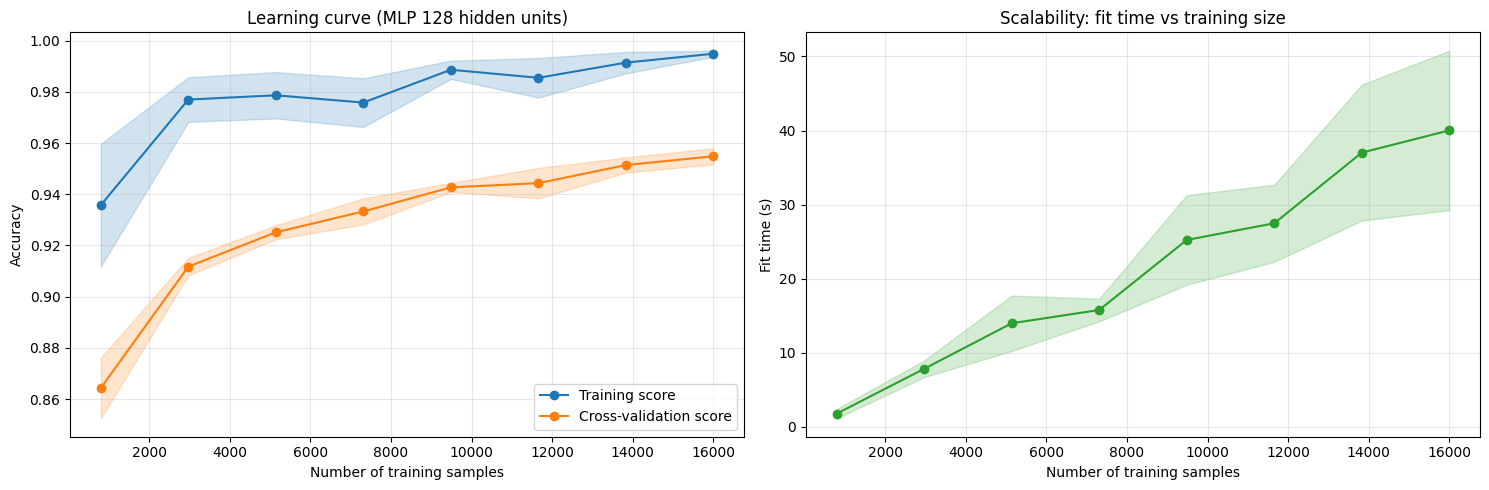

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for scores, name, color in [(train_scores, 'Training score', 'tab:blue'),
                            (val_scores, 'Cross-validation score', 'tab:orange')]:
    mean, std = scores.mean(1), scores.std(1)
    axes[0].plot(train_sizes, mean, 'o-', color=color, label=name)
    axes[0].fill_between(train_sizes, mean - std, mean + std, alpha=0.2, color=color)
axes[0].set_xlabel('Number of training samples'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Learning curve (MLP 128 hidden units)'); axes[0].legend(loc='lower right')

axes[1].plot(train_sizes, fit_times.mean(1), 'o-', color='tab:green')
axes[1].fill_between(train_sizes, fit_times.mean(1) - fit_times.std(1),
                     fit_times.mean(1) + fit_times.std(1), alpha=0.2, color='tab:green')
axes[1].set_xlabel('Number of training samples'); axes[1].set_ylabel('Fit time (s)')
axes[1].set_title('Scalability: fit time vs training size')
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:**
- با داده کم، دقت آموزش بالا ولی دقت اعتبارسنجی پایین است (**واریانس بالا**): مدل نمونه‌های کم را حفظ می‌کند.
- با افزایش داده، فاصله دو منحنی کم و دقت اعتبارسنجی بیشتر می‌شود.
- منحنی اعتبارسنجی در انتها هنوز شیب مثبت دارد؛ یعنی **داده بیشتر هنوز کمک می‌کند** (به همین دلیل مدل اصلی ما که روی ۶۰۰۰۰ نمونه آموزش دید دقت بالاتری دارد).
- نمودار سمت راست هزینه محاسباتی را نشان می‌دهد: زمان آموزش تقریباً به صورت خطی با اندازه داده رشد می‌کند.
- باند رنگی اطراف منحنی‌ها انحراف معیار بین فولدهاست و **پایداری** مدل را نشان می‌دهد.

</div>

<div dir="rtl">

## ۱۰. منحنی دقت-بازیابی (Precision-Recall Curve)

### چیست؟
مدل برای هر نمونه یک **احتمال** تولید می‌کند. برای تصمیم‌گیری باید یک **آستانه (Threshold)** انتخاب کنیم؛ مثلاً «اگر احتمال کلاس ۳ بیشتر از ۰.۵ بود، بگو ۳». با تغییر آستانه از ۱ تا ۰:
- آستانه بالا ← مدل محتاط است ← **Precision بالا، Recall پایین**
- آستانه پایین ← مدل سخاوتمند است ← **Recall بالا، Precision پایین**

منحنی PR تمام این نقاط (Recall در محور افقی، Precision در محور عمودی) را نشان می‌دهد.

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

**Average Precision (AP)** مساحت زیر منحنی PR است (هرچه به ۱ نزدیک‌تر، بهتر):
$$AP = \sum_n (R_n - R_{n-1}) P_n$$

### کاربرد
- **داده‌های نامتوازن** (مثل تشخیص بیماری، تقلب، اسپم) که در آن‌ها کلاس مثبت نادر است. در این حالت منحنی PR بسیار آموزنده‌تر از ROC است، چون به تعداد زیاد نمونه‌های منفی درست (TN) حساس نیست.
- **انتخاب آستانه** بر اساس نیاز مسئله (مثلاً «Precision باید حداقل ۹۹٪ باشد»).

### مسئله چندکلاسه
منحنی PR برای مسائل دودویی تعریف شده است. برای ۱۰ کلاس از روش **One-vs-Rest** استفاده می‌کنیم: برای هر رقم، یک مسئله دودویی «این رقم / بقیه» می‌سازیم (`label_binarize`) و از ستون متناظر در `predict_proba` استفاده می‌کنیم. **Micro-average** همه تصمیم‌های دودویی را با هم ترکیب می‌کند.

</div>

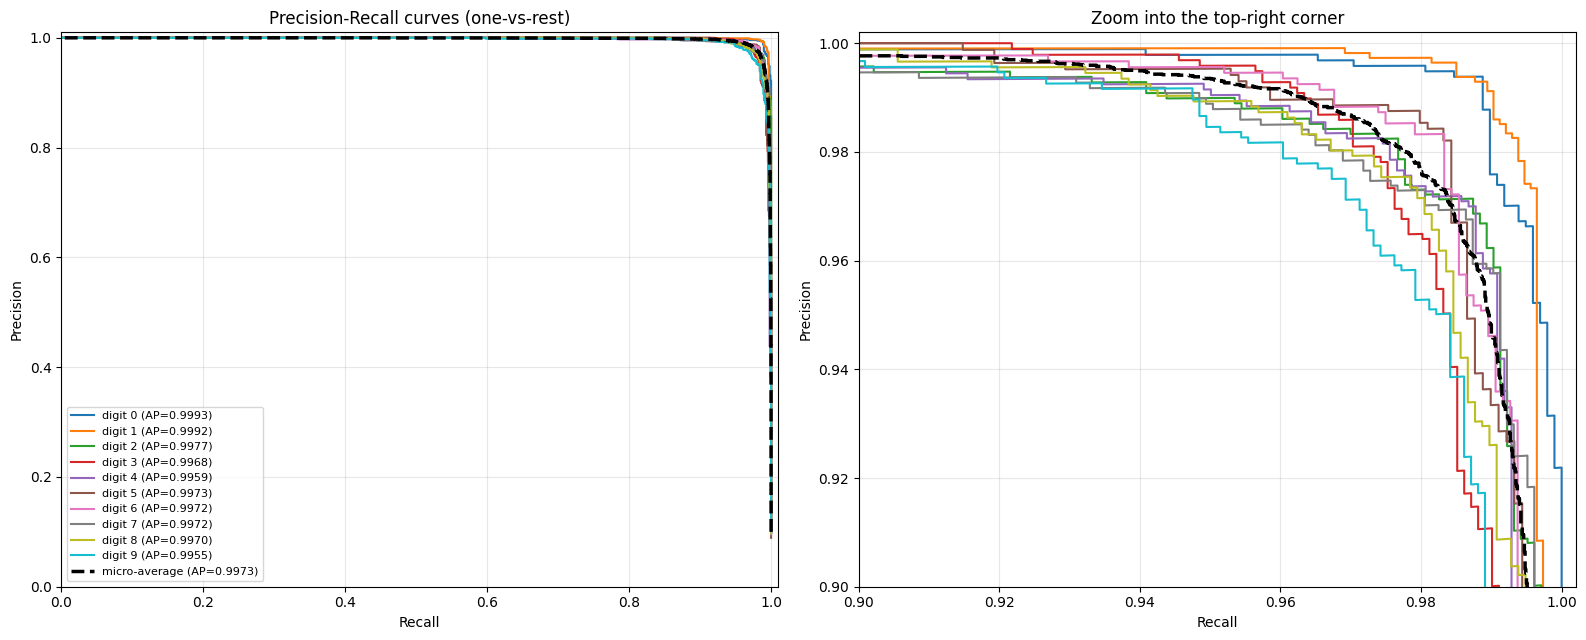

Macro-average AP: 0.99732


In [18]:
Y_test_bin = label_binarize(y_test, classes=classes)          # shape (10000, 10)
colors = plt.cm.tab10(np.arange(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
ap_per_class = {}
for k in classes:
    prec, rec, _ = precision_recall_curve(Y_test_bin[:, k], proba[:, k])
    ap_per_class[k] = average_precision_score(Y_test_bin[:, k], proba[:, k])
    for ax in axes:
        ax.plot(rec, prec, color=colors[k], lw=1.5, label=f'digit {k} (AP={ap_per_class[k]:.4f})')

prec_mi, rec_mi, _ = precision_recall_curve(Y_test_bin.ravel(), proba.ravel())
ap_micro = average_precision_score(Y_test_bin, proba, average='micro')
for ax in axes:
    ax.plot(rec_mi, prec_mi, 'k--', lw=2.5, label=f'micro-average (AP={ap_micro:.4f})')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')

axes[0].set_title('Precision-Recall curves (one-vs-rest)')
axes[0].set_xlim(0, 1.01); axes[0].set_ylim(0, 1.01)
axes[0].legend(loc='lower left', fontsize=8)
axes[1].set_title('Zoom into the top-right corner')
axes[1].set_xlim(0.9, 1.002); axes[1].set_ylim(0.9, 1.002)
plt.tight_layout()
plt.show()

print('Macro-average AP:', round(average_precision_score(Y_test_bin, proba, average='macro'), 5))

<div dir="rtl">

### ۱۰-۱. اثر آستانه روی Precision و Recall
برای رقمی که کمترین AP را دارد (سخت‌ترین کلاس)، Precision و Recall را بر حسب آستانه رسم می‌کنیم. این نمودار نشان می‌دهد چطور با انتخاب آستانه می‌توان بین این دو معیار **مصالحه (Trade-off)** کرد.

</div>

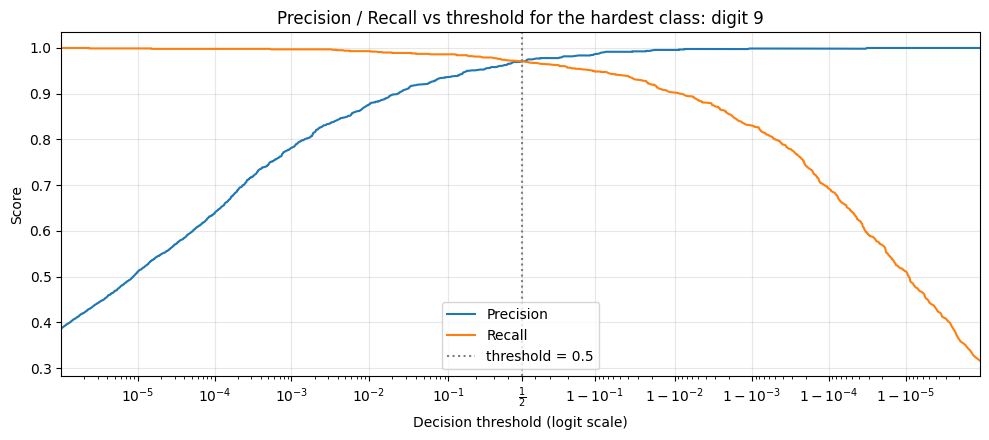

threshold=0.1   precision=0.9369  recall=0.9861
threshold=0.5   precision=0.9713  recall=0.9713
threshold=0.9   precision=0.9876  recall=0.9485
threshold=0.99  precision=0.9956  recall=0.9019


In [19]:
hard = min(ap_per_class, key=ap_per_class.get)
prec, rec, thr = precision_recall_curve(Y_test_bin[:, hard], proba[:, hard])

keep = (thr > 1e-6) & (thr < 1 - 1e-6)        # logit scale is undefined at exactly 0 and 1
plt.figure(figsize=(10, 4.5))
plt.plot(thr[keep], prec[:-1][keep], label='Precision')
plt.plot(thr[keep], rec[:-1][keep], label='Recall')
plt.axvline(0.5, color='gray', ls=':', label='threshold = 0.5')
plt.xscale('logit')      # stretches the regions near 0 and 1 where most probabilities are
plt.xlim(thr[keep].min(), thr[keep].max())
plt.xlabel('Decision threshold (logit scale)'); plt.ylabel('Score')
plt.title(f'Precision / Recall vs threshold for the hardest class: digit {hard}')
plt.legend()
plt.tight_layout()
plt.show()

for t in [0.1, 0.5, 0.9, 0.99]:
    pred_k = proba[:, hard] >= t
    tp = np.sum(pred_k & (Y_test_bin[:, hard] == 1))
    print(f'threshold={t:<5} precision={tp / max(pred_k.sum(), 1):.4f}  '
          f'recall={tp / Y_test_bin[:, hard].sum():.4f}')

<div dir="rtl">

## ۱۱. منحنی ROC (Receiver Operating Characteristic)

### چیست؟
مانند منحنی PR، با تغییر آستانه ساخته می‌شود؛ اما محورهای آن متفاوت‌اند:
- محور عمودی: **True Positive Rate (TPR)** = Recall = $\frac{TP}{TP+FN}$
- محور افقی: **False Positive Rate (FPR)** = $\frac{FP}{FP+TN}$ (درصد نمونه‌های منفی که به اشتباه مثبت شده‌اند)

**AUC (Area Under Curve)** مساحت زیر منحنی ROC است:
- AUC = 1: طبقه‌بند کامل
- AUC = 0.5: مثل پرتاب سکه (خط قطری)
- تفسیر احتمالی: **احتمال اینکه مدل به یک نمونه مثبت تصادفی امتیاز بالاتری از یک نمونه منفی تصادفی بدهد.**

### کاربرد
- مقایسه کلی مدل‌ها **مستقل از آستانه**
- وقتی هزینه FP و FN هر دو مهم است و داده تقریباً متوازن است
- در داده‌های بسیار نامتوازن، ROC ممکن است **بیش از حد خوش‌بینانه** باشد (چون TN زیاد، FPR را کوچک نگه می‌دارد)؛ آنجا PR بهتر است.

### میانگین‌گیری در حالت چندکلاسه
- **Micro-average:** همه جفت‌های (نمونه، کلاس) را یک مسئله دودویی بزرگ در نظر می‌گیرد.
- **Macro-average:** AUC هر کلاس را جدا حساب کرده و میانگین ساده می‌گیرد (همه کلاس‌ها هم‌وزن).

</div>

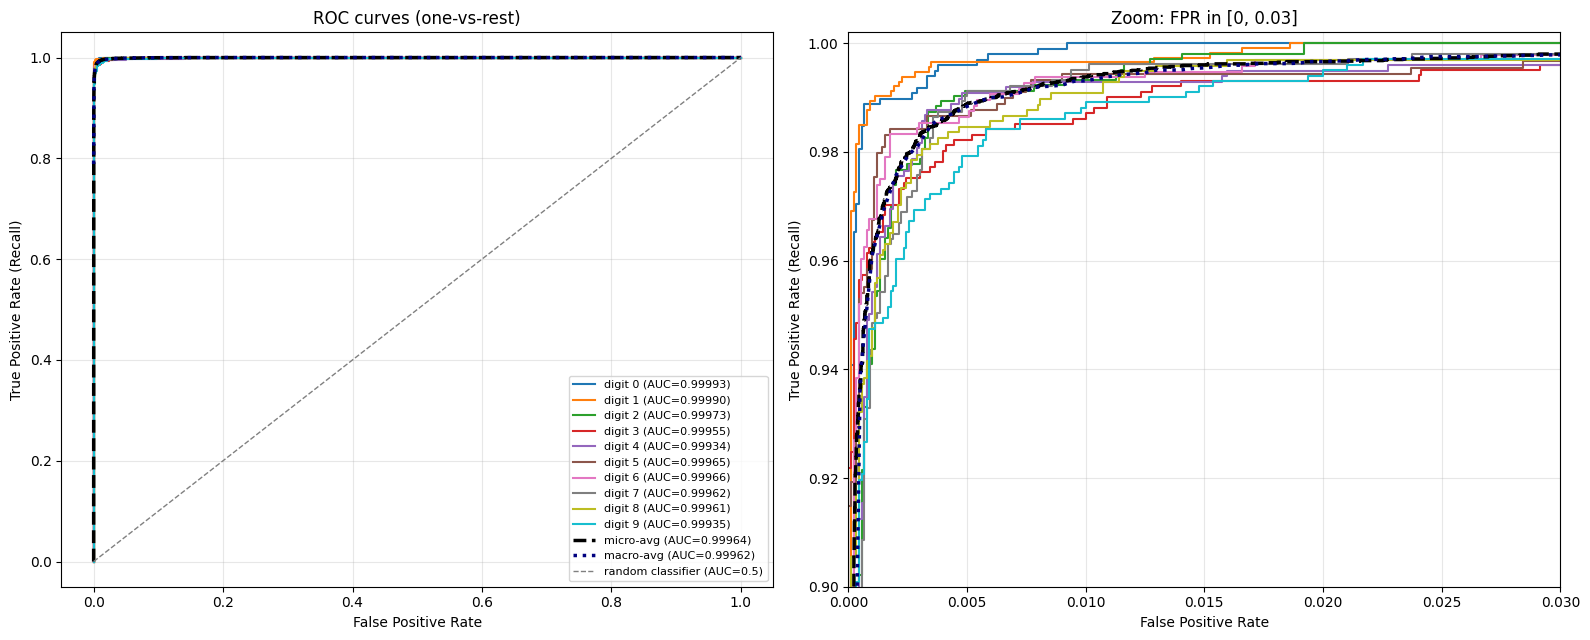

roc_auc_score (ovr, macro): 0.999635
roc_auc_score (ovo, macro): 0.999634


In [20]:
fpr, tpr, roc_auc = {}, {}, {}
for k in classes:
    fpr[k], tpr[k], _ = roc_curve(Y_test_bin[:, k], proba[:, k])
    roc_auc[k] = auc(fpr[k], tpr[k])

fpr['micro'], tpr['micro'], _ = roc_curve(Y_test_bin.ravel(), proba.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

# macro: average the TPR of all classes on a common FPR grid
fpr_grid = np.linspace(0, 1, 2001)
mean_tpr = np.mean([np.interp(fpr_grid, fpr[k], tpr[k]) for k in classes], axis=0)
fpr['macro'], tpr['macro'] = fpr_grid, mean_tpr
roc_auc['macro'] = auc(fpr_grid, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax in axes:
    for k in classes:
        ax.plot(fpr[k], tpr[k], color=colors[k], lw=1.5, label=f'digit {k} (AUC={roc_auc[k]:.5f})')
    ax.plot(fpr['micro'], tpr['micro'], 'k--', lw=2.5, label=f"micro-avg (AUC={roc_auc['micro']:.5f})")
    ax.plot(fpr['macro'], tpr['macro'], ':', color='navy', lw=2.5, label=f"macro-avg (AUC={roc_auc['macro']:.5f})")
    ax.plot([0, 1], [0, 1], color='gray', lw=1, ls='--', label='random classifier (AUC=0.5)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC curves (one-vs-rest)')
axes[0].legend(loc='lower right', fontsize=8)
axes[1].set_xlim(0, 0.03); axes[1].set_ylim(0.9, 1.002)
axes[1].set_title('Zoom: FPR in [0, 0.03]')
plt.tight_layout()
plt.show()

print('roc_auc_score (ovr, macro):', round(roc_auc_score(y_test, proba, multi_class='ovr', average='macro'), 6))
print('roc_auc_score (ovo, macro):', round(roc_auc_score(y_test, proba, multi_class='ovo', average='macro'), 6))

<div dir="rtl">

**تفسیر:** در MNIST مدل بسیار قوی است و همه منحنی‌ها به گوشه بالا-چپ چسبیده‌اند (AUC نزدیک ۱). برای دیدن تفاوت بین کلاس‌ها باید روی ناحیه FPR کوچک **زوم** کنیم. کلاس‌هایی که منحنی آن‌ها پایین‌تر است، همان کلاس‌هایی هستند که در ماتریس درهم‌ریختگی بیشترین اشتباه را داشتند.

</div>

<div dir="rtl">

## ۱۲. جمع‌بندی نمودارهای ارزیابی

| نمودار | محور افقی | محور عمودی | به چه سؤالی جواب می‌دهد؟ | کاربرد اصلی |
|---|---|---|---|---|
| **Loss Curve** | Epoch | مقدار Loss | آیا بهینه‌سازی درست کار می‌کند و همگرا شده؟ | تنظیم نرخ یادگیری و تعداد Epoch |
| **Accuracy Curve** | Epoch | دقت آموزش و اعتبارسنجی | از کجا بیش‌برازش شروع می‌شود؟ | Early Stopping، تشخیص Overfitting |
| **Learning Curve** | تعداد نمونه آموزشی | دقت آموزش و CV | آیا داده بیشتر کمک می‌کند؟ Bias یا Variance؟ | تصمیم درباره جمع‌آوری داده / پیچیدگی مدل |
| **Precision-Recall** | Recall | Precision | با تغییر آستانه، مصالحه بین FP و FN چگونه است؟ | داده‌های نامتوازن، انتخاب آستانه |
| **ROC** | FPR | TPR | مدل چقدر خوب مثبت و منفی را از هم جدا می‌کند؟ | مقایسه کلی مدل‌ها مستقل از آستانه |

> **قاعده سرانگشتی:** Loss/Accuracy Curve برای **پایش فرایند آموزش**، Learning Curve برای **تشخیص Bias/Variance**، و PR/ROC برای **ارزیابی کیفیت امتیازها (احتمالات) و انتخاب آستانه** به کار می‌روند.

</div>

<div dir="rtl">

## ۱۳. اعتبارسنجی متقابل (Cross Validation)

### چرا؟
اگر فقط یک بار داده را به آموزش/اعتبارسنجی تقسیم کنیم، نتیجه به **شانس آن تقسیم** وابسته است. در **K-Fold Cross Validation**:
1. داده به K بخش (Fold) مساوی تقسیم می‌شود.
2. K بار آموزش انجام می‌شود؛ هر بار یک Fold برای اعتبارسنجی و K-1 Fold دیگر برای آموزش.
3. میانگین و انحراف معیار K امتیاز گزارش می‌شود.

**Stratified K-Fold** تضمین می‌کند نسبت کلاس‌ها در هر Fold مثل کل داده باشد.

مزایا: تخمین **قابل‌اعتمادتر** از عملکرد، دانستن **پایداری** مدل (انحراف معیار)، و استفاده از همه داده هم برای آموزش و هم برای ارزیابی.
عیب: K برابر هزینه محاسباتی.

### ۱۳-۱. مصورسازی تقسیم‌بندی Stratified K-Fold

</div>

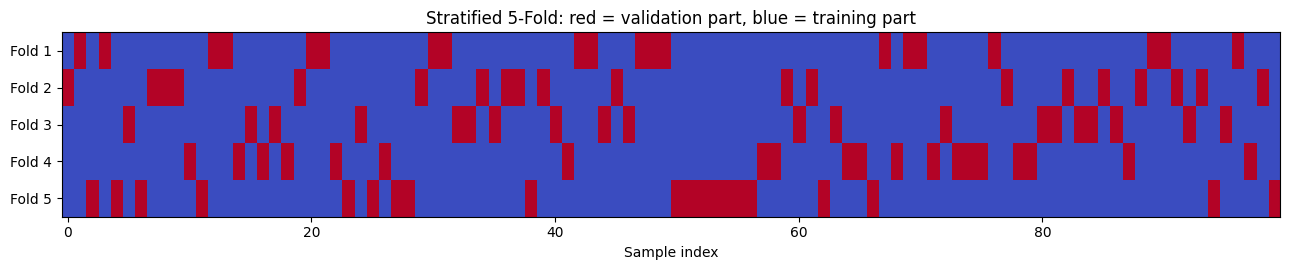

In [21]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_vis = 100                                              # visualize on the first 100 samples only
split_map = np.zeros((5, n_vis))
for f, (_, val_idx) in enumerate(cv5.split(X_train_s[:n_vis], y_train[:n_vis])):
    split_map[f, val_idx] = 1

fig, ax = plt.subplots(figsize=(13, 2.8))
ax.imshow(split_map, aspect='auto', cmap='coolwarm', interpolation='nearest')
ax.set_yticks(range(5)); ax.set_yticklabels([f'Fold {i + 1}' for i in range(5)])
ax.set_xlabel('Sample index'); ax.grid(False)
ax.set_title('Stratified 5-Fold: red = validation part, blue = training part')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۱۳-۲. اجرای 5-Fold CV روی کل ۶۰۰۰۰ داده آموزشی
از `cross_validate` استفاده می‌کنیم چون برخلاف `cross_val_score`:
- چند معیار را همزمان حساب می‌کند (`accuracy` و `f1_macro`)
- با `return_train_score=True` دقت آموزش هر Fold را هم برمی‌گرداند
- زمان آموزش (`fit_time`) و پیش‌بینی (`score_time`) را هم گزارش می‌کند

مدل را با `n_jobs=5` به صورت موازی روی ۵ Fold آموزش می‌دهیم.

</div>

In [22]:
cv_model = MLPClassifier(hidden_layer_sizes=(128,), alpha=1e-4, batch_size=128, max_iter=50,
                         early_stopping=True, n_iter_no_change=5, random_state=RANDOM_STATE)

t0 = time.time()
cv_res = cross_validate(cv_model, X_train_s, y_train, cv=cv5,
                        scoring=['accuracy', 'f1_macro'], return_train_score=True, n_jobs=5)
print(f'5-fold CV finished in {time.time() - t0:.1f} s\n')

cv_df = pd.DataFrame(cv_res)
cv_df.index = [f'Fold {i + 1}' for i in range(len(cv_df))]
display(cv_df.round(4))
print(f"Validation accuracy: {cv_df['test_accuracy'].mean():.4f} +/- {cv_df['test_accuracy'].std():.4f}")
print(f"Validation F1-macro: {cv_df['test_f1_macro'].mean():.4f} +/- {cv_df['test_f1_macro'].std():.4f}")

5-fold CV finished in 56.4 s



,fit_time,score_time,test_accuracy,train_accuracy,test_f1_macro,train_f1_macro
Fold 1,51.3499,0.0393,0.9736,0.9971,0.9733,0.9971
Fold 2,46.3161,0.0448,0.9758,0.9966,0.9756,0.9965
Fold 3,37.6652,0.0649,0.9713,0.9937,0.9710,0.9937
Fold 4,51.3259,0.0315,0.9736,0.9975,0.9735,0.9975
Fold 5,49.9815,0.0727,0.9747,0.9966,0.9744,0.9966


Validation accuracy: 0.9738 +/- 0.0017
Validation F1-macro: 0.9736 +/- 0.0017


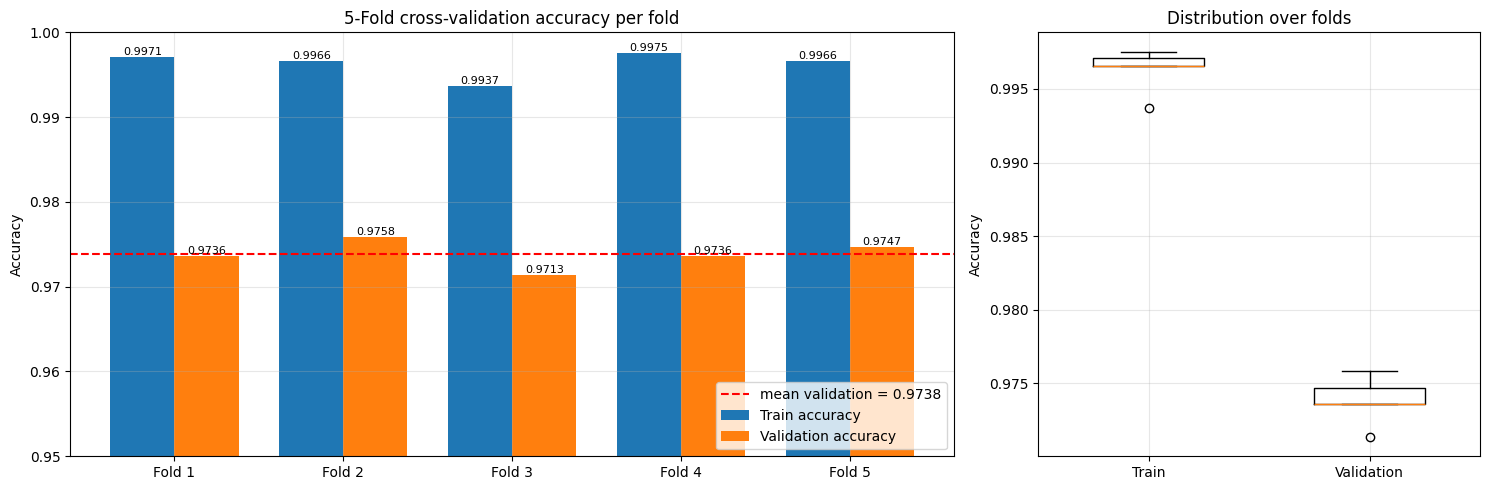

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})
x = np.arange(len(cv_df)); w = 0.38
b1 = axes[0].bar(x - w / 2, cv_df['train_accuracy'], w, label='Train accuracy', color='tab:blue')
b2 = axes[0].bar(x + w / 2, cv_df['test_accuracy'], w, label='Validation accuracy', color='tab:orange')
mean_val = cv_df['test_accuracy'].mean()
axes[0].axhline(mean_val, color='red', ls='--', label=f'mean validation = {mean_val:.4f}')
axes[0].bar_label(b1, fmt='%.4f', fontsize=8); axes[0].bar_label(b2, fmt='%.4f', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(cv_df.index)
axes[0].set_ylim(0.95, 1.0); axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-Fold cross-validation accuracy per fold'); axes[0].legend(loc='lower right')

axes[1].boxplot([cv_df['train_accuracy'], cv_df['test_accuracy']], widths=0.5)
axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['Train', 'Validation'])
axes[1].set_title('Distribution over folds'); axes[1].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۱۳-۳. مقایسه معماری‌های مختلف با Cross Validation
یکی از مهم‌ترین کاربردهای CV، **انتخاب مدل (Model Selection)** است. چند معماری مختلف را با 5-Fold CV مقایسه می‌کنیم و توزیع دقت آن‌ها را با **Box Plot** نشان می‌دهیم. (برای سرعت روی زیرمجموعه ۲۰۰۰۰تایی.)

> اگر جعبه‌های دو مدل همپوشانی زیادی داشته باشند، تفاوت آن‌ها احتمالاً معنادار نیست.

</div>

           (32,): 0.9393 +/- 0.0026  (11.4 s)


          (128,): 0.9549 +/- 0.0032  (21.0 s)


      (256, 128): 0.9618 +/- 0.0023  (27.7 s)


 (512, 256, 128): 0.9652 +/- 0.0029  (109.6 s)


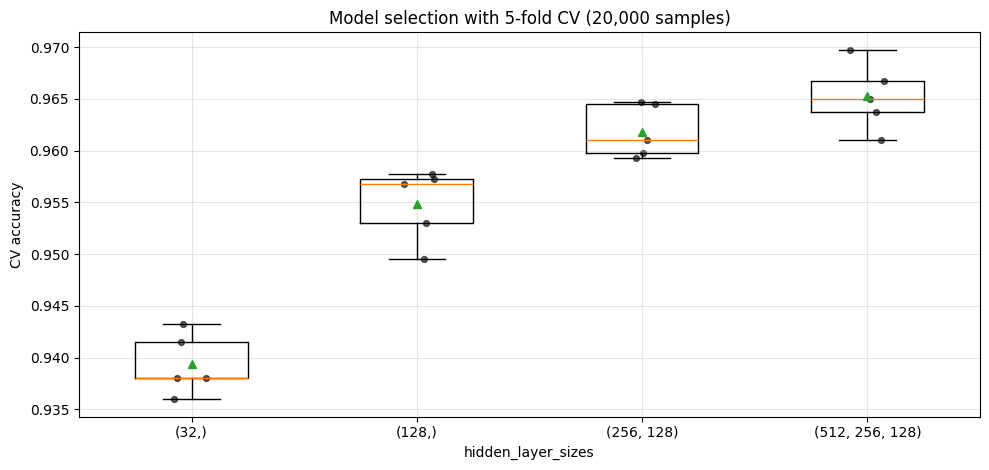

In [24]:
architectures = {'(32,)': (32,), '(128,)': (128,), '(256, 128)': (256, 128), '(512, 256, 128)': (512, 256, 128)}
arch_scores = {}
for name, hls in architectures.items():
    model = MLPClassifier(hidden_layer_sizes=hls, alpha=1e-4, batch_size=128, max_iter=50,
                          early_stopping=True, n_iter_no_change=5, random_state=RANDOM_STATE)
    t0 = time.time()
    arch_scores[name] = cross_val_score(model, X_lc, y_lc, cv=cv5, scoring='accuracy', n_jobs=-1)
    print(f'{name:>16}: {arch_scores[name].mean():.4f} +/- {arch_scores[name].std():.4f}  ({time.time() - t0:.1f} s)')

plt.figure(figsize=(10, 4.8))
plt.boxplot(list(arch_scores.values()), widths=0.5, showmeans=True)
for i, s in enumerate(arch_scores.values(), start=1):
    plt.scatter(np.full(len(s), i) + np.random.uniform(-0.08, 0.08, len(s)), s, alpha=0.6, s=18, color='k')
plt.xticks(range(1, len(arch_scores) + 1), list(arch_scores.keys()))
plt.xlabel('hidden_layer_sizes'); plt.ylabel('CV accuracy')
plt.title('Model selection with 5-fold CV (20,000 samples)')
plt.tight_layout()
plt.show()

<div dir="rtl">

### ۱۳-۴. منحنی اعتبارسنجی (Validation Curve) برای پارامتر `alpha`
`validation_curve` برای **یک ابرپارامتر** و چند مقدار مختلف، دقت CV را حساب می‌کند. محور افقی مقدار ابرپارامتر است:
- `alpha` خیلی کوچک ← تنظیم‌سازی ضعیف ← احتمال بیش‌برازش (فاصله زیاد آموزش و اعتبارسنجی)
- `alpha` خیلی بزرگ ← تنظیم‌سازی بیش از حد ← کم‌برازش (هر دو منحنی پایین می‌آیند)

</div>

validation_curve finished in 132.9 s


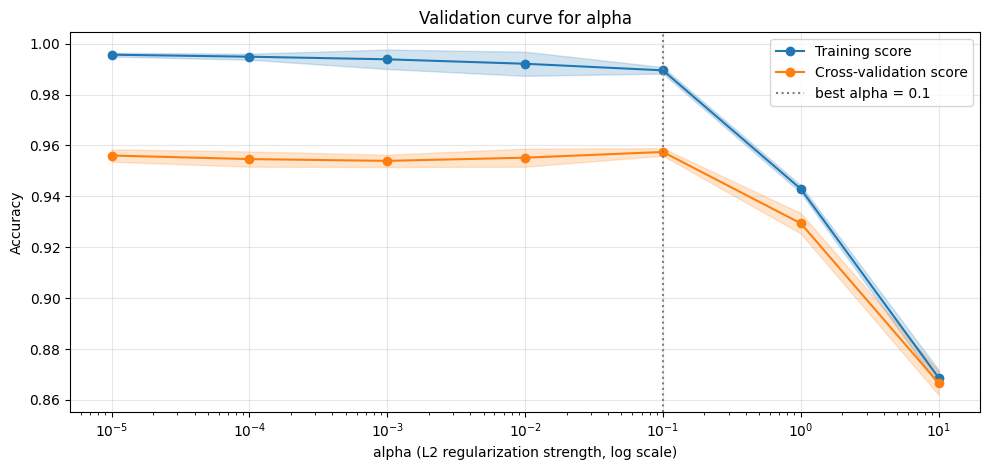

In [25]:
alphas = np.logspace(-5, 1, 7)
vc_model = MLPClassifier(hidden_layer_sizes=(128,), batch_size=128, max_iter=50,
                         early_stopping=True, n_iter_no_change=5, random_state=RANDOM_STATE)
t0 = time.time()
vc_train, vc_val = validation_curve(vc_model, X_lc, y_lc, param_name='alpha', param_range=alphas,
                                    cv=cv5, scoring='accuracy', n_jobs=-1)
print(f'validation_curve finished in {time.time() - t0:.1f} s')

plt.figure(figsize=(10, 4.8))
for scores, name, color in [(vc_train, 'Training score', 'tab:blue'), (vc_val, 'Cross-validation score', 'tab:orange')]:
    plt.semilogx(alphas, scores.mean(1), 'o-', color=color, label=name)
    plt.fill_between(alphas, scores.mean(1) - scores.std(1), scores.mean(1) + scores.std(1), alpha=0.2, color=color)
best_alpha = alphas[np.argmax(vc_val.mean(1))]
plt.axvline(best_alpha, color='gray', ls=':', label=f'best alpha = {best_alpha:g}')
plt.xlabel('alpha (L2 regularization strength, log scale)'); plt.ylabel('Accuracy')
plt.title('Validation curve for alpha'); plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر:** با بزرگ شدن `alpha`، فاصله بین دقت آموزش و اعتبارسنجی کم می‌شود (بیش‌برازش کمتر)، اما اگر خیلی بزرگ شود، وزن‌ها بیش از حد کوچک می‌شوند و هر دو دقت افت می‌کنند (کم‌برازش). بهترین مقدار جایی است که دقت اعتبارسنجی بیشینه است.

> **نکته مهم:** داده **آزمون** هرگز نباید در انتخاب ابرپارامترها استفاده شود. CV فقط روی داده آموزش انجام می‌شود و داده آزمون فقط یک بار در انتها برای گزارش نهایی به کار می‌رود.

</div>

<div dir="rtl">

## ۱۴. مصورسازی وزن‌های لایه اول

هر نورون لایه پنهان اول ۷۸۴ وزن دارد (یکی برای هر پیکسل). اگر این وزن‌ها را به شکل تصویر ۲۸×۲۸ نمایش دهیم، می‌بینیم هر نورون به دنبال چه **الگویی** در تصویر است. رنگ قرمز یعنی وزن مثبت (پیکسل روشن این نورون را فعال می‌کند) و آبی یعنی وزن منفی.

</div>

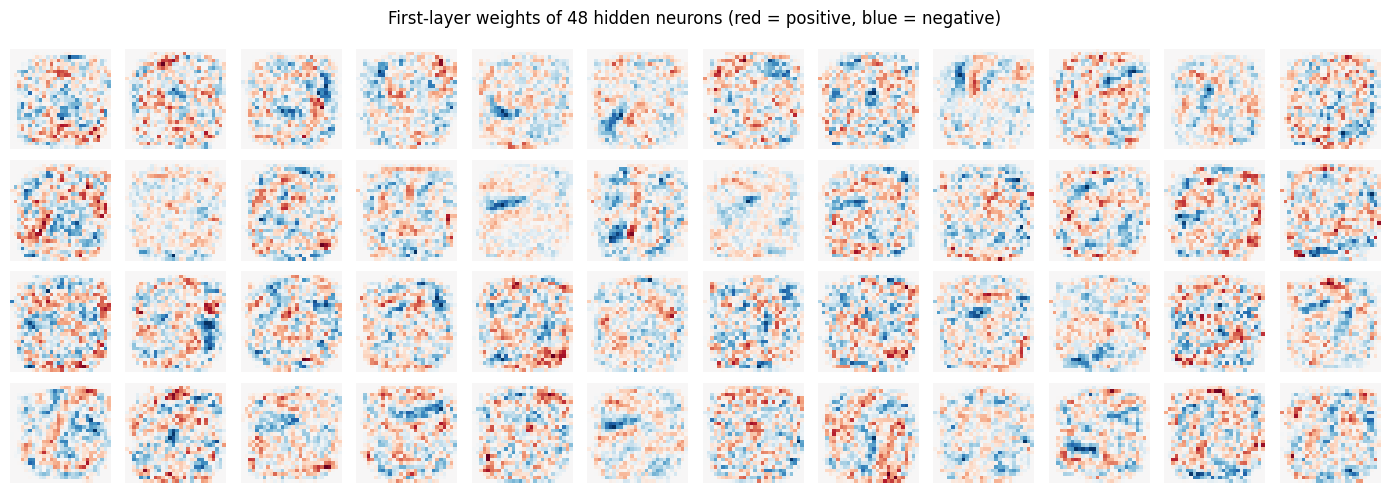

In [26]:
W1 = mlp.coefs_[0]                      # shape (784, 256)
fig, axes = plt.subplots(4, 12, figsize=(14, 5))
for i, ax in enumerate(axes.ravel()):
    w = W1[:, i].reshape(28, 28)
    v = np.abs(w).max()
    ax.imshow(w, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.axis('off')
plt.suptitle('First-layer weights of 48 hidden neurons (red = positive, blue = negative)')
plt.tight_layout()
plt.show()

<div dir="rtl">

## ۱۵. جمع‌بندی

در این نوت‌بوک:
1. یک شبکه `MLPClassifier` با معماری `784 → 256 → 128 → 10` روی ۶۰۰۰۰ تصویر MNIST آموزش دادیم و به دقت حدود **۹۸٪** روی داده آزمون رسیدیم.
2. با **Classification Report** و **Confusion Matrix** دیدیم مدل کدام ارقام را با هم اشتباه می‌گیرد.
3. **Loss Curve** و **Accuracy Curve** فرایند آموزش و شروع بیش‌برازش را نشان دادند و اهمیت **Early Stopping** و **نرخ یادگیری** مشخص شد.
4. **Learning Curve** نشان داد داده بیشتر هنوز به بهبود مدل کمک می‌کند.
5. منحنی‌های **Precision-Recall** و **ROC** کیفیت احتمالات مدل را برای هر کلاس به صورت One-vs-Rest سنجیدند.
6. با **Cross Validation** دقت مدل را به صورت قابل‌اعتماد (میانگین ± انحراف معیار) تخمین زدیم، معماری‌ها را مقایسه کردیم و `alpha` مناسب را با **Validation Curve** پیدا کردیم.

### تمرین‌ها
1. `activation='tanh'` یا `solver='sgd'` را امتحان کنید و Loss Curve را مقایسه کنید.
2. به جای تقسیم بر ۲۵۵ از `StandardScaler` استفاده کنید. آیا نتیجه تغییر می‌کند؟
3. با `GridSearchCV` بهترین ترکیب `hidden_layer_sizes` و `alpha` را پیدا کنید.
4. در بخش Accuracy Curve مقدار `alpha` را به `1e-2` تغییر دهید. آیا افزایش Loss اعتبارسنجی هنوز دیده می‌شود؟
5. Learning Curve را با `N_LC = 60000` تکرار کنید.

</div>